# Cow Behavior Classification with Vision Transformer

This notebook implements a **Vision Transformer (ViT)** for classifying cow behaviors from image crops using transfer learning and fine-tuning.

## Project Overview

- **Model**: Google's ViT-base-patch16-224-in21k (pre-trained on ImageNet-21k)
- **Task**: 5-class cow behavior classification
- **Data**: Image crops organized by behavior class
- **Approach**: Fine-tuning with early stopping and mixed precision training
- **Output**: Production-ready classifier with comprehensive evaluation

## Key Results
- **Test Accuracy**: 92.6%
- **Weighted F1-Score**: 92.57%
- **Classes**: drinking water, foraging, lying down, rumination, stand

## Data Structure
```
workdir/crops_raw/
├── drinking_water/     # 744 images
├── foraging/          # 5,710 images  
├── lying_down/        # 4,519 images
├── rumination/        # 6,079 images
└── stand/             # 8,272 images
```

## Technical Features
- Stratified train/validation/test splits (70/15/15)
- Fast image preprocessing with optimized transforms
- Mixed precision training (bf16/fp16)
- Early stopping with F1-weighted metric
- Comprehensive evaluation with confusion matrix
- Model persistence and inference pipeline
- Visual validation with sample predictions

In [1]:
# Core imports for ViT cow behavior classification
import os, random
from pathlib import Path
import numpy as np, torch
from datasets import load_dataset, DatasetDict
from transformers import (AutoImageProcessor, AutoModelForImageClassification,
                          TrainingArguments, Trainer, EarlyStoppingCallback)
import evaluate
from sklearn.metrics import confusion_matrix, classification_report

# Setup device and reproducibility
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", torch.cuda.get_device_name())
torch.manual_seed(42); np.random.seed(42); random.seed(42)

Using: NVIDIA GeForce RTX 4080


In [2]:
# Configuration - easy to modify for demo
DATA_ROOT = "workdir/crops_raw"
MODEL_CHECKPOINT = "google/vit-base-patch16-224-in21k"  # Pre-trained ViT base
EPOCHS = 10
LR = 5e-5  # Learning rate for fine-tuning
BATCH_TRAIN, BATCH_EVAL = 32, 64  # Batch sizes for training and evaluation
SEED = 42

In [3]:
# Load dataset and create stratified splits (70/15/15)
raw = load_dataset("imagefolder", data_dir=DATA_ROOT)["train"]
splits = raw.train_test_split(test_size=0.15, stratify_by_column="label", seed=SEED)
train_val = splits["train"].train_test_split(test_size=0.1765, stratify_by_column="label", seed=SEED)  # 0.15/(1-0.15)
data = DatasetDict(train=train_val["train"], validation=train_val["test"], test=splits["test"])

print(f"Dataset splits: Train={len(data['train']):,}, Val={len(data['validation']):,}, Test={len(data['test']):,}")
data

Resolving data files:   0%|          | 0/25324 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset splits: Train=17,725, Val=3,800, Test=3,799


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 17725
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 3800
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 3799
    })
})

In [4]:
import pandas as pd
from collections import Counter

class_names = data["train"].features["label"].names
train_counts = Counter(data["train"]["label"])
class_dist = pd.DataFrame({
    "Class": class_names,
    "Count": [train_counts[i] for i in range(len(class_names))],
    "Percentage": [train_counts[i]/len(data["train"])*100 for i in range(len(class_names))]
}).round(1)

print("Class Distribution:")
print(class_dist.to_string(index=False))

Class Distribution:
         Class  Count  Percentage
drinking water    520         2.9
      foraging   3997        22.6
    lying down   3163        17.8
    rumination   4255        24.0
         stand   5790        32.7


In [6]:
# Image preprocessing with HF processor
processor = AutoImageProcessor.from_pretrained(MODEL_CHECKPOINT, use_fast=True)

def preprocess(examples):
    # Ensure RGB and process with ViT processor
    images = [img.convert("RGB") for img in examples["image"]]
    # inputs = processor(images, return_tensors="pt", input_data_format="channels_last")
    inputs = processor(images)
    return {"pixel_values": inputs["pixel_values"], "labels": examples["label"]}

# Apply preprocessing and format for PyTorch
data = data.map(preprocess, batched=True, remove_columns=["image","label"])
for k in data:
    data[k].set_format("torch", columns=["pixel_values","labels"])

Map:   0%|          | 0/17725 [00:00<?, ? examples/s]

The channel dimension is ambiguous. Got image shape torch.Size([3, 11, 3]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.
The channel dimension is ambiguous. Got image shape torch.Size([3, 1, 3]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.


Map:   0%|          | 0/3800 [00:00<?, ? examples/s]

The channel dimension is ambiguous. Got image shape torch.Size([3, 9, 1]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.


Map:   0%|          | 0/3799 [00:00<?, ? examples/s]

In [7]:
# Setup label mappings and initialize model
id2label = {i: name for i, name in enumerate(class_names)}
label2id = {v:k for k,v in id2label.items()}

# Load pre-trained ViT and add classification head
model = AutoModelForImageClassification.from_pretrained(
    MODEL_CHECKPOINT, num_labels=len(id2label), id2label=id2label, label2id=label2id,
    ignore_mismatched_sizes=True
).to(device)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [8]:
# Setup evaluation metrics
acc = evaluate.load("accuracy")
f1 = evaluate.load("f1")
def compute_metrics(p):
    preds = p.predictions.argmax(-1)
    return {
        "accuracy": acc.compute(predictions=preds, references=p.label_ids)["accuracy"],
        "f1_weighted": f1.compute(predictions=preds, references=p.label_ids, average="weighted")["f1"]
    }

In [9]:
# Training configuration with mixed precision
use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
args = TrainingArguments(
    output_dir="runs/cow-behavior-vit",
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_TRAIN,
    per_device_eval_batch_size=BATCH_EVAL,
    learning_rate=LR,
    weight_decay=0.05,
    warmup_ratio=0.05,
    eval_strategy="epoch",  # Evaluate once per epoch
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True,
    bf16=use_bf16, fp16=(not use_bf16 and torch.cuda.is_available()),
    report_to="none",
    save_total_limit=1,
)

In [10]:
# Initialize trainer and start training
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=data["train"],
    eval_dataset=data["validation"],
    compute_metrics=compute_metrics,
    processing_class=processor,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

# Train the model
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,0.817900,0.476882,0.825000,0.824003
2,0.380300,0.307499,0.895263,0.893911
3,0.210000,0.292798,0.903684,0.902932
4,0.121900,0.315373,0.909474,0.909472
5,0.066600,0.345718,0.917895,0.917684
6,0.034500,0.381178,0.916053,0.915699
7,0.019700,0.406368,0.918158,0.917949
8,0.008200,0.437985,0.916316,0.915824
9,0.004600,0.414057,0.921842,0.921632
10,0.001900,0.418401,0.921579,0.921349


TrainOutput(global_step=5540, training_loss=0.15057145717153694, metrics={'train_runtime': 1927.2298, 'train_samples_per_second': 91.971, 'train_steps_per_second': 2.875, 'total_flos': 1.3735824478806528e+19, 'train_loss': 0.15057145717153694, 'epoch': 10.0})

{'eval_loss': 0.40671926736831665, 'eval_accuracy': 0.9241905764674915, 'eval_f1_weighted': 0.9239704752210576, 'eval_runtime': 28.003, 'eval_samples_per_second': 135.664, 'eval_steps_per_second': 2.143, 'epoch': 10.0}
                precision    recall  f1-score   support

drinking water       0.92      0.94      0.93       112
      foraging       0.94      0.97      0.95       856
    lying down       0.89      0.85      0.87       678
    rumination       0.88      0.90      0.89       912
         stand       0.96      0.95      0.95      1241

      accuracy                           0.92      3799
     macro avg       0.92      0.92      0.92      3799
  weighted avg       0.92      0.92      0.92      3799



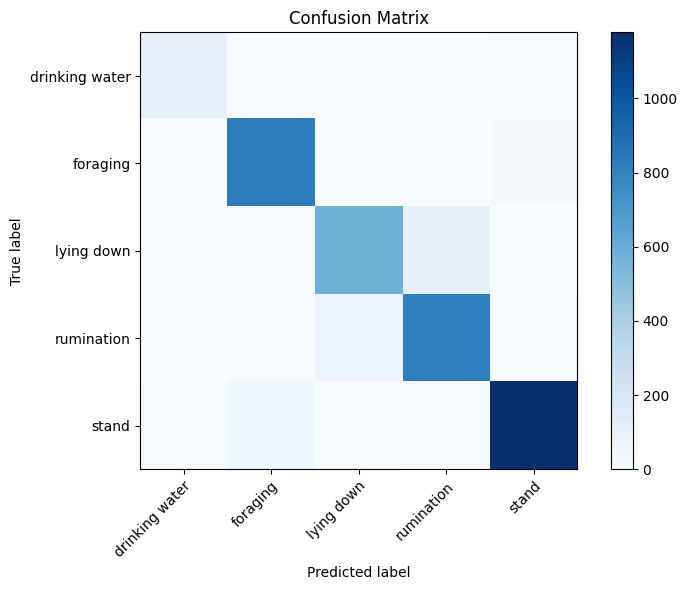

In [11]:
# Evaluate on test set and show results
test_metrics = trainer.evaluate(data["test"])
pred = trainer.predict(data["test"])
y_true = pred.label_ids
y_pred = pred.predictions.argmax(-1)

# Overall performance metrics
print(test_metrics)
print(classification_report(y_true, y_pred, target_names=list(id2label.values())))

# Confusion matrix visualization
cm = confusion_matrix(y_true, y_pred)
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]),
       xticklabels=list(id2label.values()), yticklabels=list(id2label.values()),
       title='Confusion Matrix', ylabel='True label', xlabel='Predicted label')
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
plt.tight_layout()
plt.show()

In [12]:
# Optional: Save model for use
SAVE_MODEL = True  # Set to True if you want to save the model

if SAVE_MODEL:
    trainer.save_model("models/cow-behavior-vit")
    processor.save_pretrained("models/cow-behavior-vit")
    print("Model saved to models/cow-behavior-vit")

Model saved to models/cow-behavior-vit


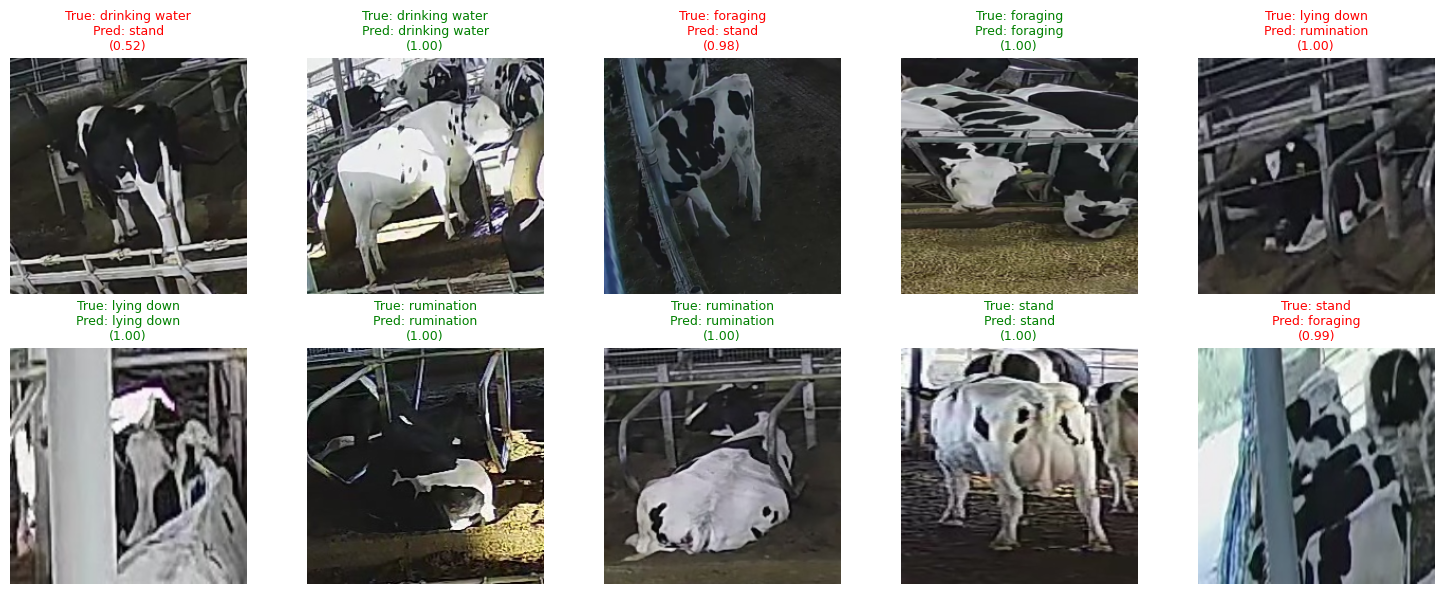

In [15]:
# Visual validation: show sample predictions
from PIL import Image
import torch.nn.functional as F

def show_sample_predictions(n_per_class=2):
    """Show sample predictions on test data"""
    # Sample images from test set
    np.random.seed(SEED)
    class_samples = {i: [] for i in range(len(id2label))}
    
    for idx, label in enumerate(data["test"]["labels"]):
        if len(class_samples[label.item()]) < n_per_class:
            class_samples[label.item()].append(idx)
    
    # Get sample indices and make predictions
    sample_indices = [idx for indices in class_samples.values() for idx in indices]
    
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    
    for i, idx in enumerate(sample_indices[:10]):
        # Get image and true label
        pixel_values = data["test"][idx]["pixel_values"].unsqueeze(0).to(device)
        true_label = data["test"][idx]["labels"].item()
        
        # Make prediction
        with torch.no_grad():
            outputs = model(pixel_values)
            pred_label = outputs.logits.argmax(-1).item()
            confidence = F.softmax(outputs.logits, dim=-1).max().item()
        
        # Convert tensor back to image for display
        img_array = pixel_values.squeeze().cpu().numpy().transpose(1, 2, 0)
        img_array = (img_array * 0.5 + 0.5)  # Denormalize
        img_array = np.clip(img_array, 0, 1)
        
        axes[i].imshow(img_array)
        axes[i].axis('off')
        
        # Color code title: green if correct, red if wrong
        color = 'green' if true_label == pred_label else 'red'
        title = f"True: {id2label[true_label]}\nPred: {id2label[pred_label]}\n({confidence:.2f})"
        axes[i].set_title(title, fontsize=9, color=color)
    
    plt.tight_layout()
    plt.show()

show_sample_predictions()